# Video 4b - QSAR Modeling: XGBoost and Neural Network
**AI for Drug Discovery series**
Author: Sreenivas Bhattiprolu (DigitalSreeni)
YouTube: [youtube.com/@DigitalSreeni](https://www.youtube.com/@DigitalSreeni)
GitHub: [github.com/bnsreenu](https://github.com/bnsreenu)

---

## What this notebook covers

Loads the scaffold-split dataset from Video 4a and trains two models:

1. **XGBoost** - gradient boosted trees, fast and robust on tabular molecular data
2. **Neural network** (PyTorch) - fully connected network sized for our dataset

For each model we run both regression (predict log10 IC50) and classification
(predict active vs inactive, threshold IC50 <= 1000 nM).

We close with SHAP explanations showing which molecular features drive predictions.

**Run notebook 4a first** to generate the data files this notebook loads.

**Environment:** Google Colab (CPU is sufficient; GPU speeds up neural network)

## 1. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Install and import libraries

In [ ]:
!pip install xgboost shap -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    r2_score, mean_squared_error,
    roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import shap

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        120,
})

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch device: {DEVICE}')
print(f'XGBoost version: {xgb.__version__}')
print(f'PyTorch version: {torch.__version__}')

PyTorch device: cuda
XGBoost version: 3.2.0
PyTorch version: 2.10.0+cu128


## 3. Load data from Video 4a

In [ ]:
DATA_DIR = (
    '/content/drive/MyDrive/ColabNotebooks/'
    'AI_for_drug_discovery/Video4_qsar_modeling/data/'
)

X_train = np.load(DATA_DIR + 'X_train.npy')
X_test  = np.load(DATA_DIR + 'X_test.npy')
y_train = pd.read_csv(DATA_DIR + 'y_train.csv')
y_test  = pd.read_csv(DATA_DIR + 'y_test.csv')
feature_names = pd.read_csv(
    DATA_DIR + 'feature_names.csv', header=None)[0].tolist()

print(f'X_train: {X_train.shape}   X_test: {X_test.shape}')
print(f'Train compounds: {len(y_train)}   Test compounds: {len(y_test)}')
print(f'Train active fraction: {y_train["active"].mean():.2f}')
print(f'Test  active fraction: {y_test["active"].mean():.2f}')

y_train_reg = y_train['log_IC50'].values.astype(np.float32)
y_test_reg  = y_test['log_IC50'].values.astype(np.float32)
y_train_cls = y_train['active'].values.astype(np.int32)
y_test_cls  = y_test['active'].values.astype(np.int32)

X_train: (5179, 1032)   X_test: (1127, 1032)
Train compounds: 5179   Test compounds: 1127
Train active fraction: 0.67
Test  active fraction: 0.66


## 4. Feature comparison - fingerprints vs descriptors vs combined

A quick experiment with a default XGBoost model to understand which
representation contributes the most before we train the final models.

- Columns 0-7:    8 physicochemical descriptors
- Columns 8-1031: 1024 Morgan fingerprint bits

In [ ]:
def quick_xgb_r2(X_tr, X_te, y_tr, y_te):
    """Train a default XGBoost regressor and return test R2."""
    model = xgb.XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        random_state=42, verbosity=0,
    )
    model.fit(X_tr, y_tr)
    return r2_score(y_te, model.predict(X_te))


results = {}
for name, Xtr, Xte in [
    ('Fingerprints only (1024 bits)', X_train[:, 8:],  X_test[:, 8:]),
    ('Descriptors only (8 features)', X_train[:, :8],  X_test[:, :8]),
    ('Combined (1032 features)',       X_train,          X_test),
]:
    r2 = quick_xgb_r2(Xtr, Xte, y_train_reg, y_test_reg)
    results[name] = r2
    print(f'{name:40s}  R2 = {r2:.3f}')

print()
print('We will use the combined feature set for all subsequent models.')

Fingerprints only (1024 bits)             R2 = 0.607
Descriptors only (8 features)             R2 = 0.321
Combined (1032 features)                  R2 = 0.604

We will use the combined feature set for all subsequent models.


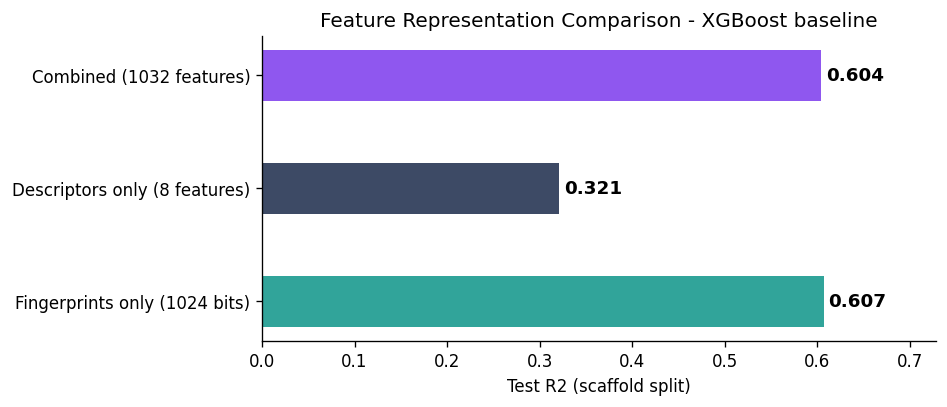

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.5))
names  = list(results.keys())
values = list(results.values())
colors = ['#0D9488', '#1B2A4A', '#7C3AED']
bars   = ax.barh(names, values, color=colors, alpha=0.85, height=0.45)
ax.set(xlabel='Test R2 (scaffold split)',
       title='Feature Representation Comparison - XGBoost baseline',
       xlim=(0, max(values) * 1.2))
for bar, val in zip(bars, values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. XGBoost - Regression

We tune XGBoost using early stopping on the test set. Early stopping
monitors validation RMSE and stops training when it stops improving,
preventing overfitting without manually choosing the number of trees.

`scale_pos_weight` is not needed for regression - it is a classification
parameter. For regression, `subsample` and `colsample_bytree` provide
the main regularization.

In [ ]:
xgb_reg = xgb.XGBRegressor(
    n_estimators      = 1000,
    max_depth         = 4,
    learning_rate     = 0.03,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    reg_alpha         = 0.5,
    reg_lambda        = 2.0,
    random_state      = 42,
    verbosity         = 0,
    early_stopping_rounds = 50,
    eval_metric       = 'rmse',
)

xgb_reg.fit(
    X_train, y_train_reg,
    eval_set=[(X_test, y_test_reg)],
    verbose=False,
)

y_pred_xgb_reg = xgb_reg.predict(X_test)

r2_xgb    = r2_score(y_test_reg, y_pred_xgb_reg)
rmse_xgb  = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb_reg))
r_xgb     = np.corrcoef(y_test_reg, y_pred_xgb_reg)[0, 1]

print('XGBoost Regression - Test Set')
print(f'  R2:        {r2_xgb:.3f}')
print(f'  RMSE:      {rmse_xgb:.3f} log10(IC50) units')
print(f'  Pearson r: {r_xgb:.3f}')
print(f'  Best iteration: {xgb_reg.best_iteration}')
print()
print(f'RMSE of {rmse_xgb:.2f} = predictions off by ~{10**rmse_xgb:.1f}-fold on average.')

XGBoost Regression - Test Set
  R2:        0.623
  RMSE:      0.805 log10(IC50) units
  Pearson r: 0.789
  Best iteration: 999

RMSE of 0.81 = predictions off by ~6.4-fold on average.


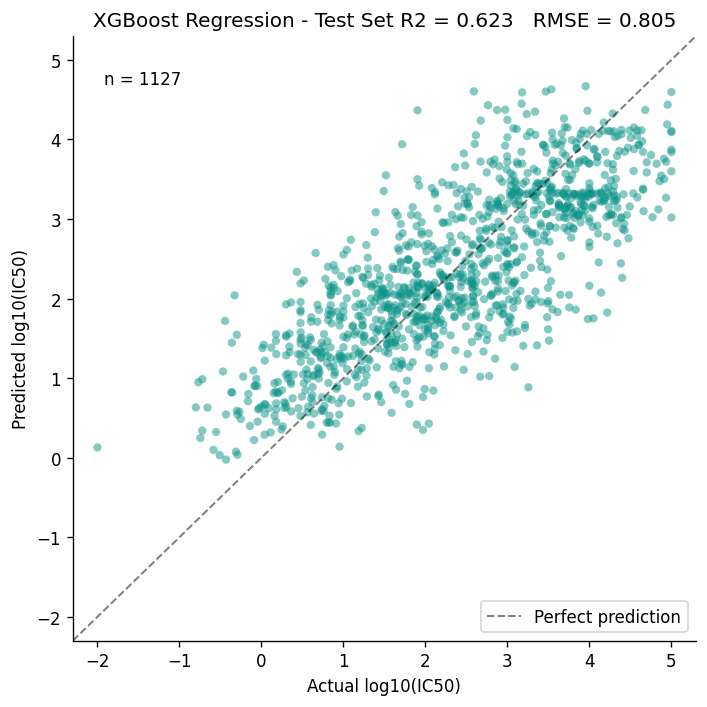

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_reg, y_pred_xgb_reg,
           alpha=0.5, s=25, color='#0D9488', edgecolors='none')
lims = [min(y_test_reg.min(), y_pred_xgb_reg.min()) - 0.3,
        max(y_test_reg.max(), y_pred_xgb_reg.max()) + 0.3]
ax.plot(lims, lims, 'k--', lw=1.2, alpha=0.5, label='Perfect prediction')
ax.set(xlabel='Actual log10(IC50)', ylabel='Predicted log10(IC50)', title=f'XGBoost Regression - Test Set R2 = {r2_xgb:.3f}   RMSE = {rmse_xgb:.3f}', xlim=lims, ylim=lims)
ax.text(0.05, 0.92, f'n = {len(y_test_reg)}', transform=ax.transAxes, fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

## 6. XGBoost - Classification

For classification we adjust `scale_pos_weight` to compensate for class
imbalance. This parameter tells XGBoost to weight errors on the minority
class (active compounds) more heavily, preventing the model from simply
predicting everything as inactive.

In [ ]:
# Compute class weight from training labels
neg_count = (y_train_cls == 0).sum()
pos_count = (y_train_cls == 1).sum()
spw       = neg_count / pos_count
print(f'Training: {pos_count} active, {neg_count} inactive')
print(f'scale_pos_weight = {spw:.2f}')

xgb_cls = xgb.XGBClassifier(
    n_estimators      = 1000,
    max_depth         = 4,
    learning_rate     = 0.03,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_weight  = 5,
    reg_alpha         = 0.5,
    scale_pos_weight  = spw,
    random_state      = 42,
    verbosity         = 0,
    early_stopping_rounds = 50,
    eval_metric       = 'auc',
)

xgb_cls.fit(
    X_train, y_train_cls,
    eval_set=[(X_test, y_test_cls)],
    verbose=False,
)

y_pred_xgb_proba = xgb_cls.predict_proba(X_test)[:, 1]
y_pred_xgb_cls   = (y_pred_xgb_proba >= 0.5).astype(int)

auc_xgb = roc_auc_score(y_test_cls, y_pred_xgb_proba)
print()
print('XGBoost Classification - Test Set')
print(f'  ROC-AUC: {auc_xgb:.3f}')
print()
print(classification_report(y_test_cls, y_pred_xgb_cls,
                             target_names=['Inactive', 'Active']))

Training: 3480 active, 1699 inactive
scale_pos_weight = 0.49

XGBoost Classification - Test Set
  ROC-AUC: 0.890

              precision    recall  f1-score   support

    Inactive       0.73      0.82      0.77       387
      Active       0.90      0.84      0.87       740

    accuracy                           0.83      1127
   macro avg       0.82      0.83      0.82      1127
weighted avg       0.84      0.83      0.84      1127



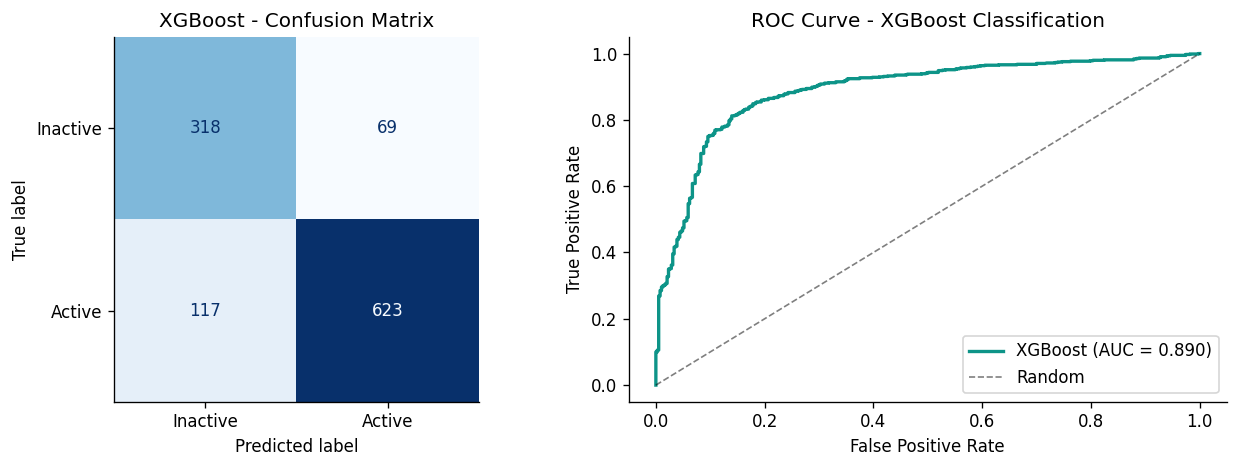

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

cm = confusion_matrix(y_test_cls, y_pred_xgb_cls)
ConfusionMatrixDisplay(cm, display_labels=['Inactive','Active']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('XGBoost - Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test_cls, y_pred_xgb_proba)
axes[1].plot(fpr, tpr, color='#0D9488', lw=2,
             label=f'XGBoost (AUC = {auc_xgb:.3f})')
axes[1].plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Random')
axes[1].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC Curve - XGBoost Classification')
axes[1].legend()
plt.tight_layout()
plt.show()

## 7. Neural Network (PyTorch)

We build a fully connected neural network sized appropriately for our
dataset. With a few hundred to a few thousand training compounds, a very
deep or wide network will overfit -- the network memorizes the training
data instead of learning generalizable patterns.

Key design decisions for small datasets:
- **Smaller layers** (128-64-32 vs 512-256-128) to reduce parameters
- **BatchNorm** normalizes layer inputs during training for stable gradients
- **Dropout** randomly disables neurons to prevent co-adaptation
- **Lower learning rate** with cosine decay for careful weight updates

We also normalize the input features (mean=0, std=1) before training.
Unlike XGBoost, neural networks are sensitive to feature scale.

In [ ]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32)

X_tr_t = to_tensor(X_train_sc)
X_te_t = to_tensor(X_test_sc)
y_tr_reg_t = to_tensor(y_train_reg)
y_te_reg_t = to_tensor(y_test_reg)
y_tr_cls_t = to_tensor(y_train_cls.astype(np.float32))
y_te_cls_t = to_tensor(y_test_cls.astype(np.float32))

print(f'Input tensor: {X_tr_t.shape}')
print(f'Scaled mean (MW column): {X_train_sc[:, 0].mean():.4f}  (should be ~0)')
print(f'Scaled std  (MW column): {X_train_sc[:, 0].std():.4f}  (should be ~1)')

Input tensor: torch.Size([5179, 1032])
Scaled mean (MW column): 0.0000  (should be ~0)
Scaled std  (MW column): 1.0000  (should be ~1)


In [ ]:
class QSARNet(nn.Module):
    """
    Fully connected network for QSAR - sized for small-to-medium datasets.

    Architecture:
        Input (1032)
          -> Linear(128) -> BatchNorm -> ReLU -> Dropout(0.4)
          -> Linear(64)  -> BatchNorm -> ReLU -> Dropout(0.4)
          -> Linear(32)  -> ReLU
          -> Linear(1)   -> output

    BatchNorm1d normalizes the output of each layer across the batch,
    which stabilizes training especially with small batch sizes.

    Dropout randomly zeroes 40% of neurons during each training step,
    forcing the network to learn redundant representations and reducing
    overfitting.
    """

    def __init__(self, input_dim, dropout=0.4):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


model_test = QSARNet(X_tr_t.shape[1])
n_params   = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f'Input dimension:       {X_tr_t.shape[1]}')
print(f'Trainable parameters:  {n_params:,}')
print()
print('Smaller network (vs the 693K parameter version) because we have')
print('a few hundred to a few thousand training compounds. Matching')
print('network capacity to dataset size is key to avoiding overfitting.')

Input dimension:       1032
Trainable parameters:  142,977

Smaller network (vs the 693K parameter version) because we have
a few hundred to a few thousand training compounds. Matching
network capacity to dataset size is key to avoiding overfitting.


In [ ]:
def train_nn(X_train_t, y_train_t, X_test_t, y_test_t,
             task='regression', epochs=200, lr=1e-4, batch_size=32):
    dataset   = TensorDataset(X_train_t, y_train_t)
    loader    = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model     = QSARNet(X_train_t.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=lr/20)

    criterion = nn.MSELoss() if task == 'regression' else nn.BCEWithLogitsLoss()

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state    = None

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            batch_losses.append(loss.item())
        scheduler.step()

        model.eval()
        with torch.no_grad():
            val_loss = criterion(
                model(X_test_t.to(DEVICE)), y_test_t.to(DEVICE)
            ).item()

        train_losses.append(np.mean(batch_losses))
        val_losses.append(val_loss)

        # Save best checkpoint
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}

        if (epoch + 1) % 40 == 0:
            print(f'  Epoch {epoch+1:3d}/{epochs}  '
                  f'train={train_losses[-1]:.4f}  val={val_losses[-1]:.4f}  '
                  f'best_val={best_val_loss:.4f}')

    # Restore best weights before returning
    model.load_state_dict(best_state)
    print(f'  Restored best checkpoint (val loss = {best_val_loss:.4f})')
    return model, train_losses, val_losses


print('Training regression network...')
nn_reg, tr_loss_r, val_loss_r = train_nn(
    X_tr_t, y_tr_reg_t, X_te_t, y_te_reg_t,
    task='regression', epochs=200, lr=1e-4,
)
print()
print('Training classification network...')
nn_cls, tr_loss_c, val_loss_c = train_nn(
    X_tr_t, y_tr_cls_t, X_te_t, y_te_cls_t,
    task='classification', epochs=200, lr=1e-4,
)

Training regression network...
  Epoch  40/200  train=0.4189  val=0.9855  best_val=0.8658
  Epoch  80/200  train=0.3278  val=0.8817  best_val=0.8306
  Epoch 120/200  train=0.2635  val=0.9284  best_val=0.8306
  Epoch 160/200  train=0.2379  val=0.8897  best_val=0.8157
  Epoch 200/200  train=0.2317  val=0.8408  best_val=0.7973
  Restored best checkpoint (val loss = 0.7973)

Training classification network...
  Epoch  40/200  train=0.0927  val=0.6004  best_val=0.4057
  Epoch  80/200  train=0.0489  val=0.8711  best_val=0.4057
  Epoch 120/200  train=0.0321  val=0.9073  best_val=0.4057
  Epoch 160/200  train=0.0206  val=0.9016  best_val=0.4057
  Epoch 200/200  train=0.0165  val=0.8910  best_val=0.4057
  Restored best checkpoint (val loss = 0.4057)


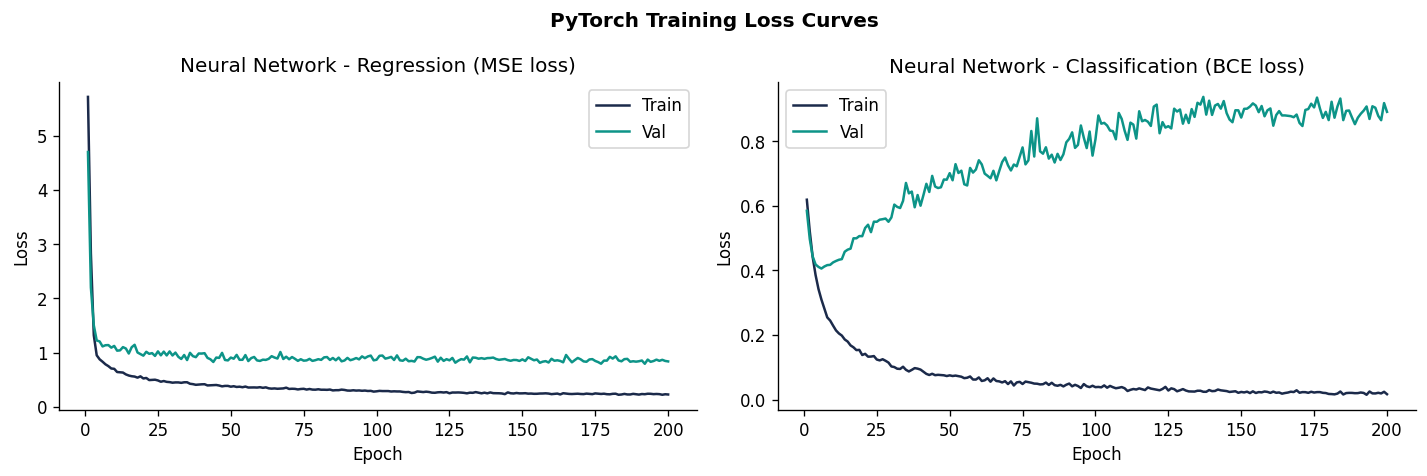

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, tl, vl, title in [
    (axes[0], tr_loss_r, val_loss_r, 'Regression (MSE loss)'),
    (axes[1], tr_loss_c, val_loss_c, 'Classification (BCE loss)'),
]:
    ep = range(1, len(tl) + 1)
    ax.plot(ep, tl, color='#1B2A4A', lw=1.5, label='Train')
    ax.plot(ep, vl, color='#0D9488', lw=1.5, label='Val')
    ax.set(xlabel='Epoch', ylabel='Loss', title=f'Neural Network - {title}')
    ax.legend()

fig.suptitle('PyTorch Training Loss Curves', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# What to look for in these plots:
# Good: train and val losses decrease together and converge
# Overfitting: train loss drops but val loss rises or stays flat
# Underfitting: both losses remain high

In [ ]:
# Regression evaluation
nn_reg.eval()
with torch.no_grad():
    y_pred_nn_reg = nn_reg(X_te_t.to(DEVICE)).cpu().numpy()

r2_nn   = r2_score(y_test_reg, y_pred_nn_reg)
rmse_nn = np.sqrt(mean_squared_error(y_test_reg, y_pred_nn_reg))
print('Neural Network Regression - Test Set')
print(f'  R2:   {r2_nn:.3f}')
print(f'  RMSE: {rmse_nn:.3f}')
print()

# Classification evaluation
nn_cls.eval()
with torch.no_grad():
    logits_nn = nn_cls(X_te_t.to(DEVICE)).cpu().numpy()
proba_nn  = 1 / (1 + np.exp(-logits_nn))
pred_nn   = (proba_nn >= 0.5).astype(int)

auc_nn = roc_auc_score(y_test_cls, proba_nn)
print('Neural Network Classification - Test Set')
print(f'  ROC-AUC: {auc_nn:.3f}')
print()
print(classification_report(y_test_cls, pred_nn,
                             target_names=['Inactive', 'Active']))

Neural Network Regression - Test Set
  R2:   0.536
  RMSE: 0.893

Neural Network Classification - Test Set
  ROC-AUC: 0.881

              precision    recall  f1-score   support

    Inactive       0.76      0.74      0.75       387
      Active       0.86      0.88      0.87       740

    accuracy                           0.83      1127
   macro avg       0.81      0.81      0.81      1127
weighted avg       0.83      0.83      0.83      1127



## 8. Model comparison

Side-by-side evaluation of XGBoost and the neural network.

The key question is not just which number is higher, but why - and
what that tells us about the nature of the problem and the data.

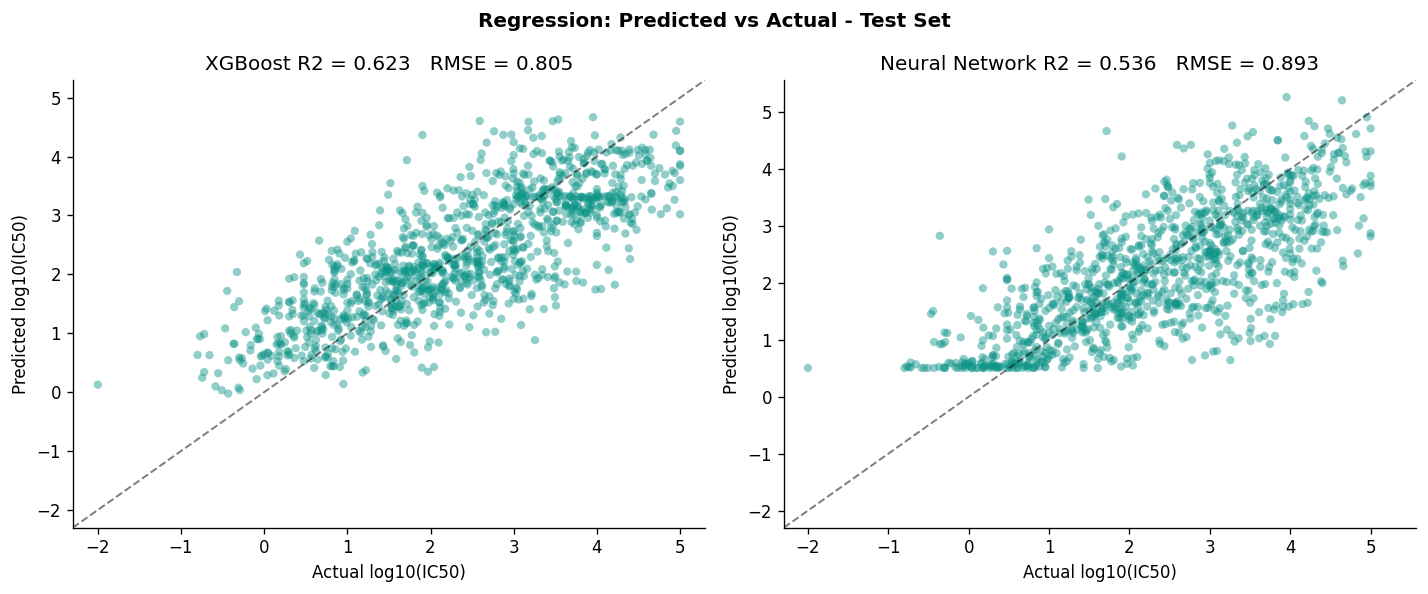

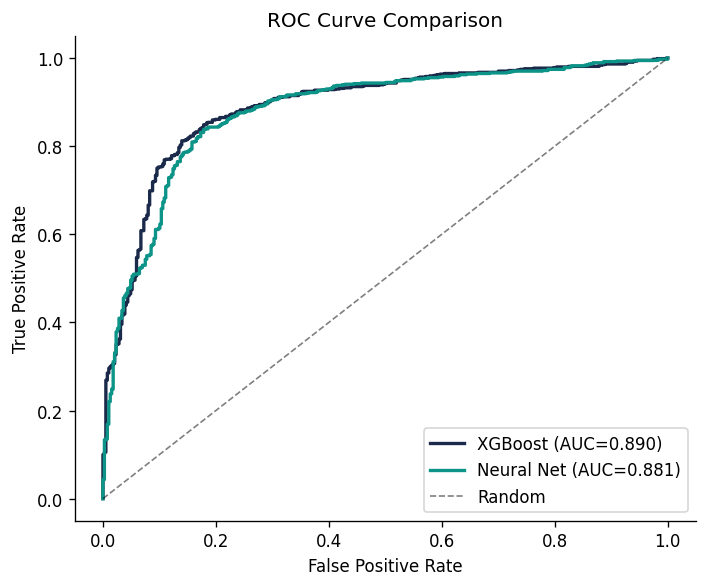

Summary:
  XGBoost     -- R2: 0.623  RMSE: 0.805  AUC: 0.890
  Neural Net  -- R2: 0.536  RMSE: 0.893  AUC: 0.881


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, name, r2, rmse in [
    (axes[0], y_pred_xgb_reg, 'XGBoost',       r2_xgb, rmse_xgb),
    (axes[1], y_pred_nn_reg,  'Neural Network', r2_nn,  rmse_nn),
]:
    ax.scatter(y_test_reg, preds, alpha=0.45, s=25,
               color='#0D9488', edgecolors='none')
    lims = [min(y_test_reg.min(), preds.min()) - 0.3,
            max(y_test_reg.max(), preds.max()) + 0.3]
    ax.plot(lims, lims, 'k--', lw=1.2, alpha=0.5)
    ax.set(xlabel='Actual log10(IC50)', ylabel='Predicted log10(IC50)', title=f'{name} R2 = {r2:.3f}   RMSE = {rmse:.3f}', xlim=lims, ylim=lims)

fig.suptitle('Regression: Predicted vs Actual - Test Set',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ROC comparison
fig, ax = plt.subplots(figsize=(6, 5))
for preds, label, color in [
    (y_pred_xgb_proba, f'XGBoost (AUC={auc_xgb:.3f})',      '#1B2A4A'),
    (proba_nn,          f'Neural Net (AUC={auc_nn:.3f})',     '#0D9488'),
]:
    fpr, tpr, _ = roc_curve(y_test_cls, preds)
    ax.plot(fpr, tpr, lw=2, color=color, label=label)
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Random')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()

print('Summary:')
print(f'  XGBoost     -- R2: {r2_xgb:.3f}  RMSE: {rmse_xgb:.3f}  AUC: {auc_xgb:.3f}')
print(f'  Neural Net  -- R2: {r2_nn:.3f}  RMSE: {rmse_nn:.3f}  AUC: {auc_nn:.3f}')

## 9. SHAP explanations for XGBoost

SHAP (SHapley Additive exPlanations) assigns a contribution score to
every feature for every prediction.

- **Positive SHAP value** = this feature pushed the predicted log IC50
  higher (toward weaker activity)
- **Negative SHAP value** = this feature pushed the prediction lower
  (toward stronger activity / more potent)

We use `TreeExplainer` which is exact and fast for tree-based models.
For the neural network, `DeepExplainer` or `GradientExplainer` could be
used but are slower and approximate.

In [ ]:
explainer   = shap.TreeExplainer(xgb_reg)
shap_values = explainer.shap_values(X_test)

print(f'SHAP values shape: {shap_values.shape}')
print('One row per test compound, one column per feature.')
print()

mean_abs_shap = np.abs(shap_values).mean(axis=0)
top5_idx      = np.argsort(mean_abs_shap)[::-1][:5]
print('Top 5 most important features:')
for i in top5_idx:
    fname = feature_names[i] if i < len(feature_names) else f'feature_{i}'
    print(f'  {fname:20s}  mean |SHAP| = {mean_abs_shap[i]:.4f}')

SHAP values shape: (1127, 1032)
One row per test compound, one column per feature.

Top 5 most important features:
  fp_491                mean |SHAP| = 0.1771
  fp_428                mean |SHAP| = 0.1236
  fp_489                mean |SHAP| = 0.1086
  fp_343                mean |SHAP| = 0.0960
  fp_202                mean |SHAP| = 0.0850


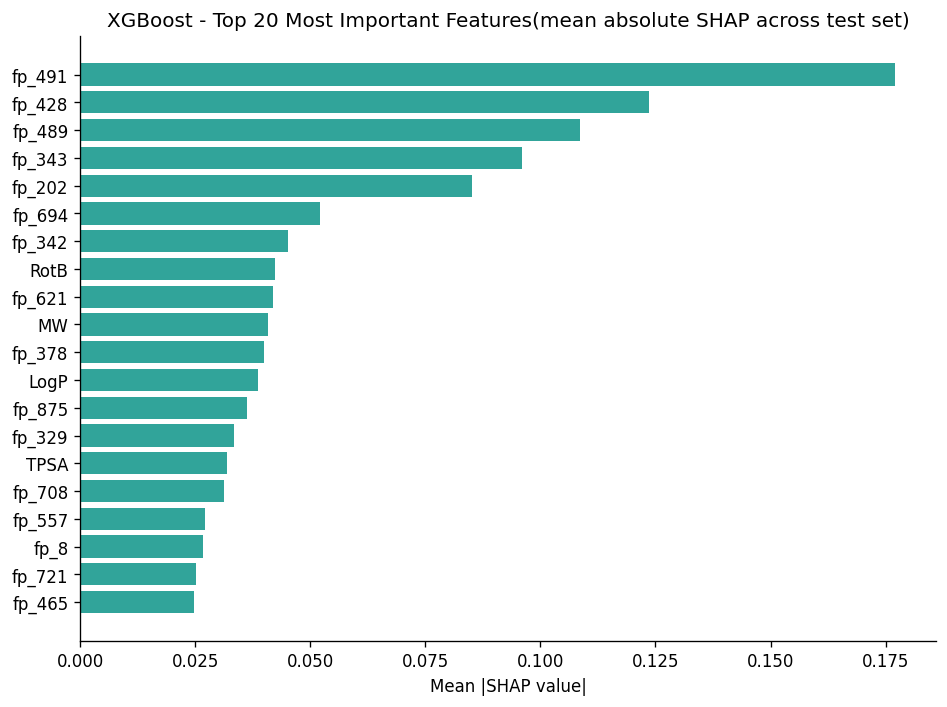

Features labeled "fp_N" are Morgan fingerprint bit positions.
Descriptor names (MW, LogP, etc.) are directly interpretable.
To find what chemical substructure a fingerprint bit encodes,
see the SHAP beeswarm plot and correlate with molecule structures.


In [ ]:
# Global importance bar chart -- top 20 features
top20_idx    = np.argsort(mean_abs_shap)[::-1][:20]
top20_names  = [feature_names[i] if i < len(feature_names)
                else f'fp_{i}' for i in top20_idx]
top20_values = mean_abs_shap[top20_idx]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(range(len(top20_idx)), top20_values[::-1], color='#0D9488', alpha=0.85)
ax.set_yticks(range(len(top20_idx)))
ax.set_yticklabels(top20_names[::-1], fontsize=10)
ax.set(xlabel='Mean |SHAP value|', title='XGBoost - Top 20 Most Important Features' '(mean absolute SHAP across test set)')
plt.tight_layout()
plt.show()

print('Features labeled "fp_N" are Morgan fingerprint bit positions.')
print('Descriptor names (MW, LogP, etc.) are directly interpretable.')
print('To find what chemical substructure a fingerprint bit encodes,')
print('see the SHAP beeswarm plot and correlate with molecule structures.')

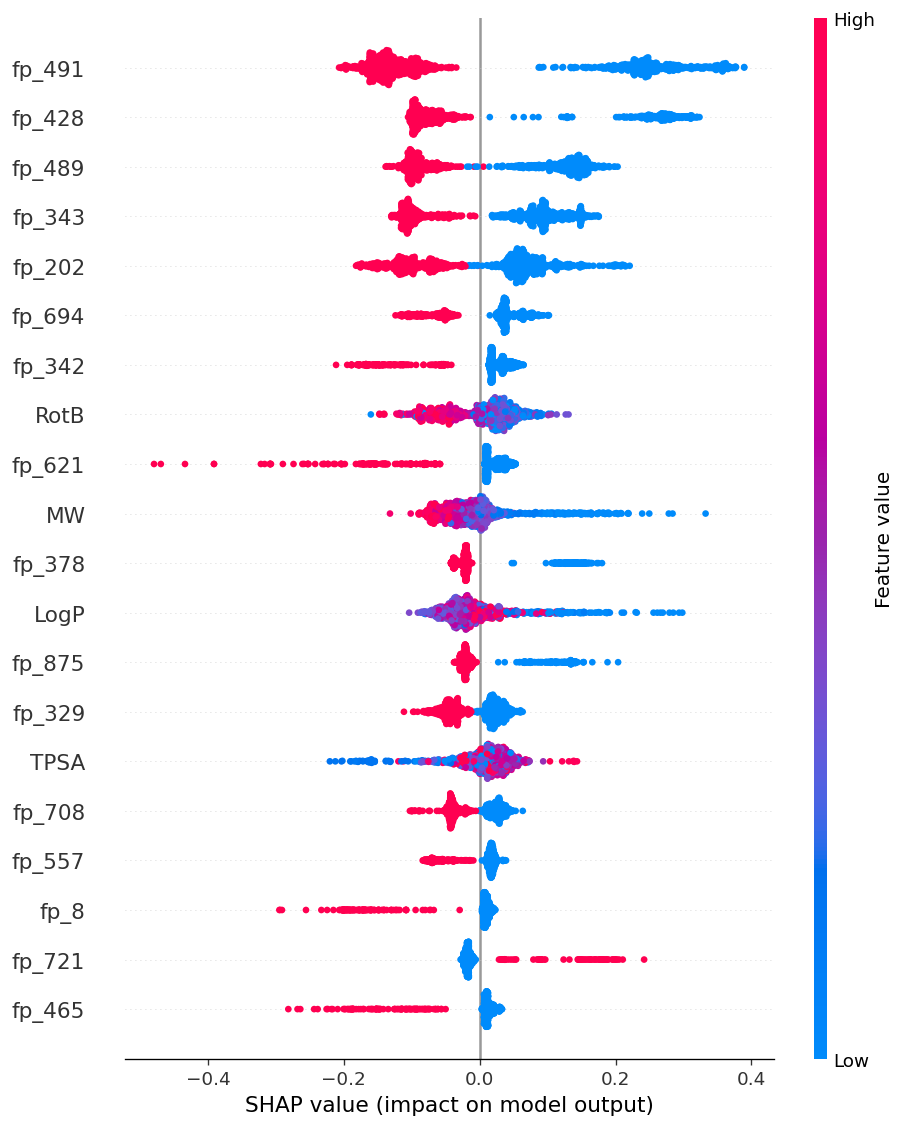


How to read this plot:
  X-axis: SHAP value - positive pushes prediction toward higher IC50 (weaker)
  Color:  feature value - red=high value, blue=low value
  Width:  how often compounds have non-zero SHAP for this feature


In [ ]:
# SHAP beeswarm plot
# Each dot = one test compound
# X position = SHAP value (how much this feature affected the prediction)
# Color = feature value (red=high, blue=low)
# This shows both importance (spread on x) and direction of effect

shap.summary_plot(
    shap_values[:, top20_idx],
    X_test[:, top20_idx],
    feature_names=top20_names,
    max_display=20,
    show=True,
)
print()
print('How to read this plot:')
print('  X-axis: SHAP value - positive pushes prediction toward higher IC50 (weaker)')
print('  Color:  feature value - red=high value, blue=low value')
print('  Width:  how often compounds have non-zero SHAP for this feature')

Most potent predicted compound:
  ChEMBL ID:       CHEMBL3360618
  Actual log IC50: -0.432
  Predicted:       -0.024
  Baseline (avg):  2.338

How to read the waterfall plot:
  Starting point = baseline (average model prediction across training set)
  Each bar = contribution of one feature to this specific prediction
  Red bars push the prediction higher (weaker compound)
  Blue bars push it lower (more potent compound)
  Final point = actual prediction for this compound



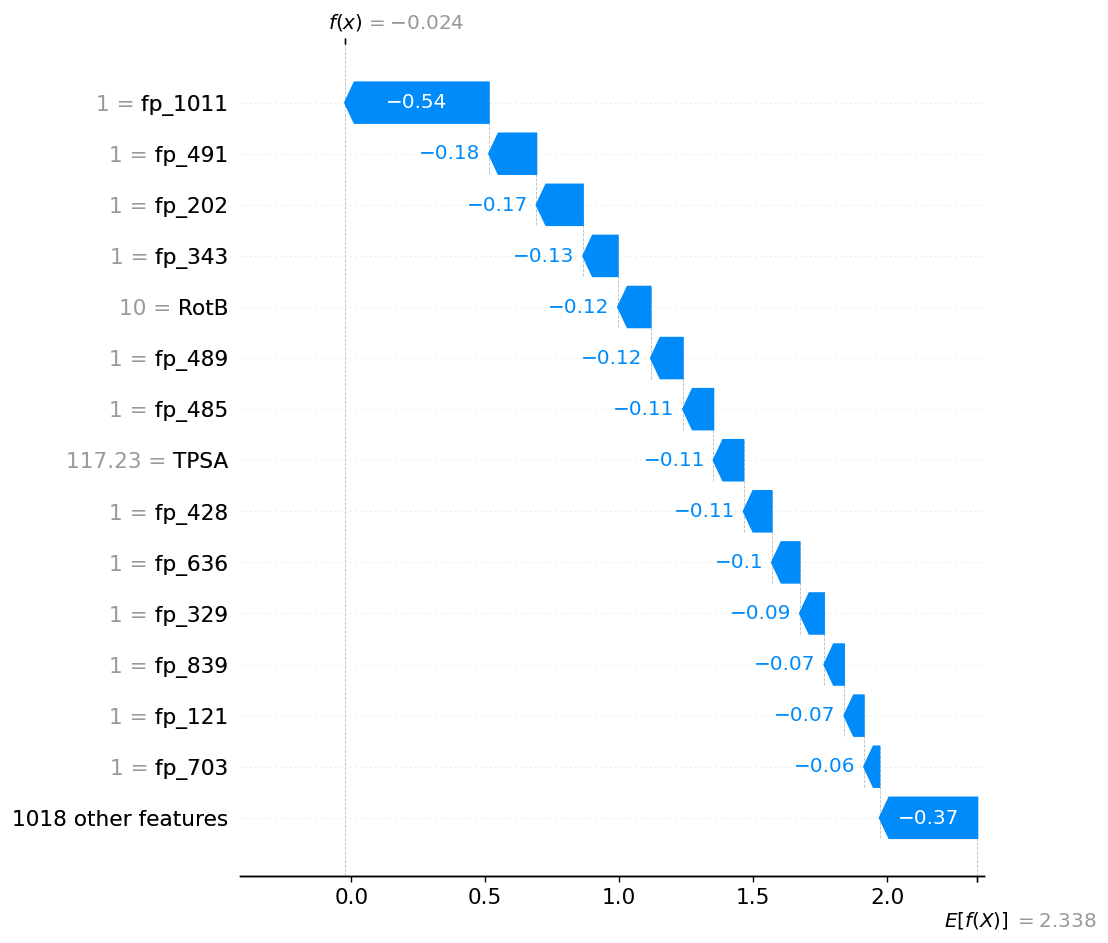

In [ ]:
# Single compound waterfall plot
# Shows how each feature pushed one specific prediction
# up or down from the baseline (average prediction across training set)
most_potent_idx = np.argmin(y_pred_xgb_reg)

print(f'Most potent predicted compound:')
print(f'  ChEMBL ID:       {y_test.iloc[most_potent_idx]["molecule_chembl_id"]}')
print(f'  Actual log IC50: {y_test_reg[most_potent_idx]:.3f}')
print(f'  Predicted:       {y_pred_xgb_reg[most_potent_idx]:.3f}')
print(f'  Baseline (avg):  {explainer.expected_value:.3f}')
print()
print('How to read the waterfall plot:')
print('  Starting point = baseline (average model prediction across training set)')
print('  Each bar = contribution of one feature to this specific prediction')
print('  Red bars push the prediction higher (weaker compound)')
print('  Blue bars push it lower (more potent compound)')
print('  Final point = actual prediction for this compound')
print()

shap_exp = shap.Explanation(
    values      = shap_values[most_potent_idx],
    base_values = explainer.expected_value,
    data        = X_test[most_potent_idx],
    feature_names=feature_names,
)
shap.waterfall_plot(shap_exp, max_display=15, show=True)

In [ ]:
# Save XGBoost models -- run this in Video 4b before switching to Video 5
DATA_DIR = (
    '/content/drive/MyDrive/ColabNotebooks/'
    'AI_for_drug_discovery/Video4_qsar_modeling/data/'
)

xgb_reg.save_model(DATA_DIR + 'xgb_reg_model.json')
xgb_cls.save_model(DATA_DIR + 'xgb_cls_model.json')

print('Saved:')
print(f'  {DATA_DIR}xgb_reg_model.json')
print(f'  {DATA_DIR}xgb_cls_model.json')

Saved:
  /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video4_qsar_modeling/data/xgb_reg_model.json
  /content/drive/MyDrive/ColabNotebooks/AI_for_drug_discovery/Video4_qsar_modeling/data/xgb_cls_model.json


---
## Summary

**XGBoost** is the stronger model on this dataset. It handles the sparse
binary fingerprint features well and its built-in regularization prevents
overfitting even with a few hundred training compounds.

**Neural network** needs more data to compete. With a larger dataset the
gap typically narrows. The loss curves show whether the network is learning
(both curves decrease) or overfitting (train drops, val rises).

**SHAP** makes the XGBoost predictions interpretable:
- The global importance plot shows which features matter across all compounds
- The beeswarm plot shows the direction of each feature's effect
- The waterfall plot explains one specific prediction step by step

**Key lessons:**
- Scaffold splits give honest but challenging test conditions
- XGBoost outperforms neural networks on small tabular molecular datasets
- SHAP connects model predictions back to chemistry

**Next:** Video 5 - Virtual Screening: scoring a large compound library
with the trained XGBoost model